## Project Title

**Kenya National Economic & Development Intelligence Dashboard**

## Notebook Description

This notebook analyzes Kenya’s national economic and development indicators using World Bank time-series data. The dataset contains multiple indicators covering the economy, population, education, health, infrastructure, technology, environment, trade, and social development from 1960 to the latest available year.

The goal of this project is to clean, transform, analyze, and prepare the data for a professional Power BI dashboard and an executive report. The notebook will convert the raw wide-format dataset into an analytics-ready structure, identify key national trends, compare development indicators over time, and generate insights that support evidence-based decision-making.

## What We Will Build

We will build an analytics pipeline that prepares data for the **Kenya National Economic & Development Intelligence Dashboard**.

The final dashboard will include:

1. **Executive Overview**

   * GDP growth
   * Inflation
   * Population growth
   * Trade balance
   * Economic health summary

2. **Economic Performance**

   * GDP trends
   * Inflation movement
   * Exports and imports
   * Investment and revenue indicators

3. **Human Development**

   * Life expectancy
   * Education indicators
   * Poverty indicators
   * Health and social progress

4. **Infrastructure & Digital Economy**

   * Electricity access
   * Internet usage
   * Mobile subscriptions
   * Urbanization trends

5. **Development Risk & Outlook**

   * Economic stress indicators
   * Long-term development patterns
   * Forecast-ready datasets
   * Policy and investment insights

## Dataset Explanation

The project uses three World Bank files:

* **API_KEN_DS2_en_csv_v2_5938.csv**
  Main Kenya indicator dataset containing yearly values for each development indicator.

* **Metadata_Country_API_KEN_DS2_en_csv_v2_5938.csv**
  Country metadata file with details about Kenya, including region and income classification.

* **Metadata_Indicator_API_KEN_DS2_en_csv_v2_5938.csv**
  Indicator metadata file explaining the meaning, source, and topic of each indicator.

## Final Output

By the end of this notebook, we will produce:

* Cleaned indicator dataset
* Long-format time-series dataset
* Selected dashboard-ready indicators
* Power BI-ready CSV files
* Key insights for the executive report
* A strong foundation for a GitHub portfolio project


In [160]:
# ==========================================
# IMPORT LIBRARIES
# ==========================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("Libraries imported successfully.")

Libraries imported successfully.


In [161]:
# ==========================================
# LOAD DATASETS
# ==========================================

main_df = pd.read_csv("API_KEN_DS2_en_csv_v2_5938.csv", skiprows=4)

country_meta = pd.read_csv("Metadata_Country_API_KEN_DS2_en_csv_v2_5938.csv")

indicator_meta = pd.read_csv("Metadata_Indicator_API_KEN_DS2_en_csv_v2_5938.csv")

print("Main Dataset Shape:", main_df.shape)
print("Country Metadata Shape:", country_meta.shape)
print("Indicator Metadata Shape:", indicator_meta.shape)

Main Dataset Shape: (1486, 71)
Country Metadata Shape: (1, 6)
Indicator Metadata Shape: (1486, 5)


In [162]:
# Preview dataset
main_df.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,1966,1967,1968,1969,1970,1971,1972,1973,1974,1975,1976,1977,1978,1979,1980,1981,1982,1983,1984,1985,1986,1987,1988,1989,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
0,Kenya,KEN,"Internally displaced persons, new displacement...",VC.IDP.NWDS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10000.000000,92000.000000,54000.000000,19000.000000,98000.000000,180000.000000,1400.000000,105000.000000,4.900000e+04,35000.000000,336000.000000,74000.000000,335000.000000,36000.000000,318000.000000,641000.000000,NaN,NaN,NaN
1,Kenya,KEN,Transport services (% of commercial service ex...,TX.VAL.TRAN.ZS.WT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.697712e+01,52.266336,3.889140e+01,39.653368,44.173375,42.114937,40.295512,37.846048,3.912143e+01,38.889887,3.454639e+01,3.128124e+01,3.003894e+01,2.997719e+01,2.910463e+01,32.047044,31.622924,31.635455,5.659350e+01,56.032267,59.493847,5.569008e+01,4.880123e+01,48.362907,50.763199,56.593503,56.032267,59.493847,55.690083,48.801230,48.358975,49.979006,46.777090,50.844809,49.347645,54.700073,52.111879,53.076674,54.040175,51.785952,52.622825,4.603231e+01,42.878083,42.345836,47.114626,32.441265,33.364268,34.839385,29.308730,29.272267,NaN,NaN
2,Kenya,KEN,"Computer, communications and other services (%...",TX.VAL.OTHR.ZS.WT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.607238e+01,11.910670,1.945701e+01,16.939176,13.931889,11.183018,4.990243,4.682503,5.491090e+00,5.209269,4.322894e+00,3.078137e+00,4.283013e+00,2.842205e+00,2.862699e+00,7.129964,9.329059,9.228374,4.199398e+00,6.186933,3.455912,3.210052e+00,1.068969e+01,12.990245,14.807614,4.199398,6.186933,3.455912,3.210052,10.689686,12.989163,15.046142,14.991766,19.023789,18.619375,14.091070,14.475291,16.380149,17.434984,21.607225,18.804098,1.868434e+01,17.247652,16.323495,17.223310,22.346221,24.188235,18.004547,13.293216,12.980601,NaN,NaN
3,Kenya,KEN,"Merchandise exports by the reporting economy, ...",TX.VAL.MRCH.RS.ZS,0.00000,0.000000,0.000000,0.000000,0.000000,0.0,1.237638e-15,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.861902e-15,0.000000,1.134189e-14,0.000000,0.000000,0.000000,0.000000,0.000000,-7.030997e-15,0.000000,-1.022381e-13,-2.982878e-13,-1.121936e-13,7.032316e-14,7.774826e-14,0.000000,0.000000,0.000000,-1.841216e-13,0.000000,0.000000,4.401977e-14,-1.514019e-13,0.000000,0.000000,0.000000,0.073149,0.028744,0.000452,0.004790,0.009108,0.000453,0.001466,0.000052,0.001524,0.015139,0.005827,0.000024,0.000000,0.000000,0.339199,4.231871e-07,0.000000,0.503800,0.000084,0.001691,0.008876,0.006300,0.007285,NaN,NaN,NaN
4,Kenya,KEN,Merchandise exports to low- and middle-income ...,TX.VAL.MRCH.R3.ZS,0.40568,0.393314,0.273473,0.246508,0.232558,NaN,6.644518e-02,0.072202,0.133652,0.102329,0.093589,0.083556,0.162753,0.117914,0.104321,1.129017e-01,0.067705,1.997996e-02,0.024436,0.006183,0.003754,0.014928,NaN,NaN,NaN,NaN,NaN,6.177277e-03,7.439398e-02,7.439398e-02,NaN,0.005480,0.020381,5.457489e-02,0.084923,0.080009,4.993346e-02,6.038995e-02,0.079874,0.166423,0.209384,0.236718,0.094299,0.256279,0.369969,0.243317,0.150118,0.187613,0.149505,0.089329,0.084437,0.079709,0.107898,0.136589,0.630366,0.585212,4.615607e-01,0.458185,0.251096,0.140933,0.123891,0.123046,0.276358,0.194086,NaN,NaN,NaN


In [163]:
# Dataset information
main_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1486 entries, 0 to 1485
Data columns (total 71 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Country Name    1486 non-null   str    
 1   Country Code    1486 non-null   str    
 2   Indicator Name  1486 non-null   str    
 3   Indicator Code  1486 non-null   str    
 4   1960            210 non-null    float64
 5   1961            242 non-null    float64
 6   1962            245 non-null    float64
 7   1963            252 non-null    float64
 8   1964            284 non-null    float64
 9   1965            301 non-null    float64
 10  1966            302 non-null    float64
 11  1967            309 non-null    float64
 12  1968            309 non-null    float64
 13  1969            312 non-null    float64
 14  1970            437 non-null    float64
 15  1971            457 non-null    float64
 16  1972            460 non-null    float64
 17  1973            449 non-null    float64
 18 

In [164]:
# Check missing values
main_df.isnull().sum().sort_values(ascending=False).head(20)

Unnamed: 70    1486
2025           1370
1960           1276
1961           1244
1962           1241
1963           1234
1964           1202
1965           1185
1966           1184
1967           1177
1968           1177
1969           1174
1970           1049
1974           1042
1973           1037
1971           1029
1972           1026
1975            973
1978            967
1976            965
dtype: int64

Understanding the Dataset Structure

The dataset is currently in a wide format where:

Each row represents a development indicator
Each column from 1960 onward represents yearly values
Indicators cover multiple sectors including:
Economy
Population
Health
Education
Infrastructure
Technology
Environment

To make the dataset suitable for analytics and Power BI dashboards, the data will later be transformed into a long time-series format.

In [165]:
# ==========================================
# CHECK DATASET COLUMNS
# ==========================================

main_df.columns

Index(['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code',
       '1960', '1961', '1962', '1963', '1964', '1965', '1966', '1967', '1968',
       '1969', '1970', '1971', '1972', '1973', '1974', '1975', '1976', '1977',
       '1978', '1979', '1980', '1981', '1982', '1983', '1984', '1985', '1986',
       '1987', '1988', '1989', '1990', '1991', '1992', '1993', '1994', '1995',
       '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004',
       '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013',
       '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022',
       '2023', '2024', '2025', 'Unnamed: 70'],
      dtype='str')

In [166]:
# ==========================================
# REMOVE EMPTY / UNNECESSARY COLUMNS
# ==========================================

main_df = main_df.dropna(axis=1, how='all')

print("New Dataset Shape:", main_df.shape)
main_df.head()

New Dataset Shape: (1486, 70)


,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,1966,1967,1968,1969,1970,1971,1972,1973,1974,1975,1976,1977,1978,1979,1980,1981,1982,1983,1984,1985,1986,1987,1988,1989,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
0,Kenya,KEN,"Internally displaced persons, new displacement...",VC.IDP.NWDS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10000.000000,92000.000000,54000.000000,19000.000000,98000.000000,180000.000000,1400.000000,105000.000000,4.900000e+04,35000.000000,336000.000000,74000.000000,335000.000000,36000.000000,318000.000000,641000.000000,NaN,NaN
1,Kenya,KEN,Transport services (% of commercial service ex...,TX.VAL.TRAN.ZS.WT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.697712e+01,52.266336,3.889140e+01,39.653368,44.173375,42.114937,40.295512,37.846048,3.912143e+01,38.889887,3.454639e+01,3.128124e+01,3.003894e+01,2.997719e+01,2.910463e+01,32.047044,31.622924,31.635455,5.659350e+01,56.032267,59.493847,5.569008e+01,4.880123e+01,48.362907,50.763199,56.593503,56.032267,59.493847,55.690083,48.801230,48.358975,49.979006,46.777090,50.844809,49.347645,54.700073,52.111879,53.076674,54.040175,51.785952,52.622825,4.603231e+01,42.878083,42.345836,47.114626,32.441265,33.364268,34.839385,29.308730,29.272267,NaN
2,Kenya,KEN,"Computer, communications and other services (%...",TX.VAL.OTHR.ZS.WT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.607238e+01,11.910670,1.945701e+01,16.939176,13.931889,11.183018,4.990243,4.682503,5.491090e+00,5.209269,4.322894e+00,3.078137e+00,4.283013e+00,2.842205e+00,2.862699e+00,7.129964,9.329059,9.228374,4.199398e+00,6.186933,3.455912,3.210052e+00,1.068969e+01,12.990245,14.807614,4.199398,6.186933,3.455912,3.210052,10.689686,12.989163,15.046142,14.991766,19.023789,18.619375,14.091070,14.475291,16.380149,17.434984,21.607225,18.804098,1.868434e+01,17.247652,16.323495,17.223310,22.346221,24.188235,18.004547,13.293216,12.980601,NaN
3,Kenya,KEN,"Merchandise exports by the reporting economy, ...",TX.VAL.MRCH.RS.ZS,0.00000,0.000000,0.000000,0.000000,0.000000,0.0,1.237638e-15,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.861902e-15,0.000000,1.134189e-14,0.000000,0.000000,0.000000,0.000000,0.000000,-7.030997e-15,0.000000,-1.022381e-13,-2.982878e-13,-1.121936e-13,7.032316e-14,7.774826e-14,0.000000,0.000000,0.000000,-1.841216e-13,0.000000,0.000000,4.401977e-14,-1.514019e-13,0.000000,0.000000,0.000000,0.073149,0.028744,0.000452,0.004790,0.009108,0.000453,0.001466,0.000052,0.001524,0.015139,0.005827,0.000024,0.000000,0.000000,0.339199,4.231871e-07,0.000000,0.503800,0.000084,0.001691,0.008876,0.006300,0.007285,NaN,NaN
4,Kenya,KEN,Merchandise exports to low- and middle-income ...,TX.VAL.MRCH.R3.ZS,0.40568,0.393314,0.273473,0.246508,0.232558,NaN,6.644518e-02,0.072202,0.133652,0.102329,0.093589,0.083556,0.162753,0.117914,0.104321,1.129017e-01,0.067705,1.997996e-02,0.024436,0.006183,0.003754,0.014928,NaN,NaN,NaN,NaN,NaN,6.177277e-03,7.439398e-02,7.439398e-02,NaN,0.005480,0.020381,5.457489e-02,0.084923,0.080009,4.993346e-02,6.038995e-02,0.079874,0.166423,0.209384,0.236718,0.094299,0.256279,0.369969,0.243317,0.150118,0.187613,0.149505,0.089329,0.084437,0.079709,0.107898,0.136589,0.630366,0.585212,4.615607e-01,0.458185,0.251096,0.140933,0.123891,0.123046,0.276358,0.194086,NaN,NaN


In [167]:
# ==========================================
# BASIC DATASET SUMMARY
# ==========================================

print("Number of Indicators:", main_df["Indicator Name"].nunique())
print("Country:", main_df["Country Name"].unique())
print("Country Code:", main_df["Country Code"].unique())
print("Number of Columns:", main_df.shape[1])
print("Number of Rows:", main_df.shape[0])

Number of Indicators: 1486
Country: <StringArray>
['Kenya']
Length: 1, dtype: str
Country Code: <StringArray>
['KEN']
Length: 1, dtype: str
Number of Columns: 70
Number of Rows: 1486


In [168]:
# ==========================================
# IDENTIFY YEAR COLUMNS
# ==========================================

year_columns = [col for col in main_df.columns if col.isdigit()]

print("First Year:", min(year_columns))
print("Last Year:", max(year_columns))
print("Total Year Columns:", len(year_columns))

First Year: 1960
Last Year: 2025
Total Year Columns: 66


In [169]:
# ==========================================
# CONVERT WIDE DATA TO LONG FORMAT
# ==========================================

long_df = main_df.melt(
    id_vars=["Country Name", "Country Code", "Indicator Name", "Indicator Code"],
    value_vars=year_columns,
    var_name="Year",
    value_name="Value"
)

long_df["Year"] = long_df["Year"].astype(int)

print("Long Dataset Shape:", long_df.shape)
long_df.head()

Long Dataset Shape: (98076, 6)


,Country Name,Country Code,Indicator Name,Indicator Code,Year,Value
0,Kenya,KEN,"Internally displaced persons, new displacement...",VC.IDP.NWDS,1960,NaN
1,Kenya,KEN,Transport services (% of commercial service ex...,TX.VAL.TRAN.ZS.WT,1960,NaN
2,Kenya,KEN,"Computer, communications and other services (%...",TX.VAL.OTHR.ZS.WT,1960,NaN
3,Kenya,KEN,"Merchandise exports by the reporting economy, ...",TX.VAL.MRCH.RS.ZS,1960,0.00000
4,Kenya,KEN,Merchandise exports to low- and middle-income ...,TX.VAL.MRCH.R3.ZS,1960,0.40568


In [170]:
# ==========================================
# CHECK MISSING VALUES IN LONG DATA
# ==========================================

missing_summary = long_df.isnull().sum()

missing_summary

Country Name          0
Country Code          0
Indicator Name        0
Indicator Code        0
Year                  0
Value             54367
dtype: int64

In [171]:
# ==========================================
# REMOVE EMPTY VALUE ROWS
# ==========================================

long_clean_df = long_df.dropna(subset=["Value"]).copy()

print("Before Cleaning:", long_df.shape)
print("After Cleaning:", long_clean_df.shape)
print("Rows Removed:", long_df.shape[0] - long_clean_df.shape[0])

long_clean_df.head()

Before Cleaning: (98076, 6)
After Cleaning: (43709, 6)
Rows Removed: 54367


,Country Name,Country Code,Indicator Name,Indicator Code,Year,Value
3,Kenya,KEN,"Merchandise exports by the reporting economy, ...",TX.VAL.MRCH.RS.ZS,1960,0.000000e+00
4,Kenya,KEN,Merchandise exports to low- and middle-income ...,TX.VAL.MRCH.R3.ZS,1960,4.056795e-01
5,Kenya,KEN,Merchandise exports to high-income economies (...,TX.VAL.MRCH.HI.ZS,1960,8.387424e+01
10,Kenya,KEN,Merchandise imports by the reporting economy (...,TM.VAL.MRCH.WL.CD,1960,2.295000e+08
11,Kenya,KEN,Merchandise imports from low- and middle-incom...,TM.VAL.MRCH.R4.ZS,1960,8.888889e+00


In [172]:
# ==========================================
# SAVE CLEANED LONG DATASET
# ==========================================

long_clean_df.to_csv("kenya_worldbank_indicators_long_clean.csv", index=False)

print("Cleaned long dataset saved successfully.")

Cleaned long dataset saved successfully.


In [173]:
# ==========================================
# VIEW SAMPLE INDICATORS
# ==========================================

long_clean_df["Indicator Name"].unique()[:50]

<StringArray>
[                                  'Merchandise exports by the reporting economy, residual (% of total merchandise exports)',
 'Merchandise exports to low- and middle-income economies in Latin America & the Caribbean (% of total merchandise exports)',
                                             'Merchandise exports to high-income economies (% of total merchandise exports)',
                                                                'Merchandise imports by the reporting economy (current US$)',
  'Merchandise imports from low- and middle-income economies in Middle East & North Africa (% of total merchandise imports)',
                 'Merchandise imports from low- and middle-income economies outside region (% of total merchandise imports)',
                                                                                                          'Urban population',
                                                                                                        

In [174]:
# ==========================================
# TOTAL UNIQUE INDICATORS
# ==========================================

total_indicators = long_clean_df["Indicator Name"].nunique()

print("Total Indicators:", total_indicators)

Total Indicators: 1387


In [175]:
# ==========================================
# SEARCH GDP RELATED INDICATORS
# ==========================================

gdp_indicators = long_clean_df[
    long_clean_df["Indicator Name"].str.contains("GDP", case=False, na=False)
]

gdp_indicators["Indicator Name"].unique()[:30]

<StringArray>
[                                  'Merchandise trade (% of GDP)',
              'External balance on goods and services (% of GDP)',
                       'Imports of goods and services (% of GDP)',
    'General government final consumption expenditure (% of GDP)',
                                'Military expenditure (% of GDP)',
                       'Exports of goods and services (% of GDP)',
                       'Final consumption expenditure (% of GDP)',
 'Households and NPISHs final consumption expenditure (% of GDP)',
                             'GDP per capita (constant 2015 US$)',
                                        'GDP (constant 2015 US$)',
                                   'GDP per capita (current LCU)',
                     'GDP deflator (base year varies by country)',
                          'Manufacturing, value added (% of GDP)',
                                               'Trade (% of GDP)',
                              'Gross domestic sa

In [176]:
# ==========================================
# STRATEGIC DASHBOARD INDICATORS
# ==========================================

key_indicators = [

    # ECONOMY
    'GDP growth (annual %)',
    'GDP (current US$)',
    'Inflation, consumer prices (annual %)',

    # POPULATION
    'Population, total',

    # HEALTH
    'Life expectancy at birth, total (years)',

    # EDUCATION
    'School enrollment, primary (% gross)',

    # TECHNOLOGY
    'Individuals using the Internet (% of population)',

    # INFRASTRUCTURE
    'Access to electricity (% of population)',

    # EMPLOYMENT
    'Unemployment, total (% of total labor force)',

]

In [177]:
# ==========================================
# FILTER EXECUTIVE DASHBOARD DATA
# ==========================================

dashboard_df = long_clean_df[
    long_clean_df["Indicator Name"].isin(key_indicators)
].copy()

print("Dashboard Dataset Shape:", dashboard_df.shape)

dashboard_df.head()

Dashboard Dataset Shape: (435, 6)


,Country Name,Country Code,Indicator Name,Indicator Code,Year,Value
44,Kenya,KEN,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,1960,4.847700e+01
339,Kenya,KEN,"Population, total",SP.POP.TOTL,1960,7.695307e+06
1172,Kenya,KEN,GDP (current US$),NY.GDP.MKTP.CD,1960,7.912655e+08
1331,Kenya,KEN,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,1960,1.243781e+00
1530,Kenya,KEN,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,1961,4.933000e+01


In [178]:
# ==========================================
# COUNT RECORDS PER INDICATOR
# ==========================================

dashboard_df["Indicator Name"].value_counts()

Indicator Name
Life expectancy at birth, total (years)             65
Population, total                                   65
GDP (current US$)                                   65
Inflation, consumer prices (annual %)               65
GDP growth (annual %)                               64
School enrollment, primary (% gross)                49
Individuals using the Internet (% of population)    31
Access to electricity (% of population)             31
Name: count, dtype: int64

In [179]:
# ==========================================
# CREATE INDICATOR CATEGORIES
# ==========================================

category_mapping = {

    'GDP growth (annual %)': 'Economy',
    'GDP (current US$)': 'Economy',
    'Inflation, consumer prices (annual %)': 'Economy',

    'Population, total': 'Population',

    'Life expectancy at birth, total (years)': 'Health',

    'School enrollment, primary (% gross)': 'Education',

    'Individuals using the Internet (% of population)': 'Technology',

    'Access to electricity (% of population)': 'Infrastructure',

    'Unemployment, total (% of total labor force)': 'Labor'

}

dashboard_df["Category"] = dashboard_df["Indicator Name"].map(category_mapping)

dashboard_df.head()

,Country Name,Country Code,Indicator Name,Indicator Code,Year,Value,Category
44,Kenya,KEN,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,1960,4.847700e+01,Health
339,Kenya,KEN,"Population, total",SP.POP.TOTL,1960,7.695307e+06,Population
1172,Kenya,KEN,GDP (current US$),NY.GDP.MKTP.CD,1960,7.912655e+08,Economy
1331,Kenya,KEN,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,1960,1.243781e+00,Economy
1530,Kenya,KEN,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,1961,4.933000e+01,Health


In [180]:
# ==========================================
# SAVE FINAL DASHBOARD DATASET
# ==========================================

dashboard_df.to_csv(
    "kenya_dashboard_dataset.csv",
    index=False
)

print("Dashboard dataset saved successfully.")

Dashboard dataset saved successfully.


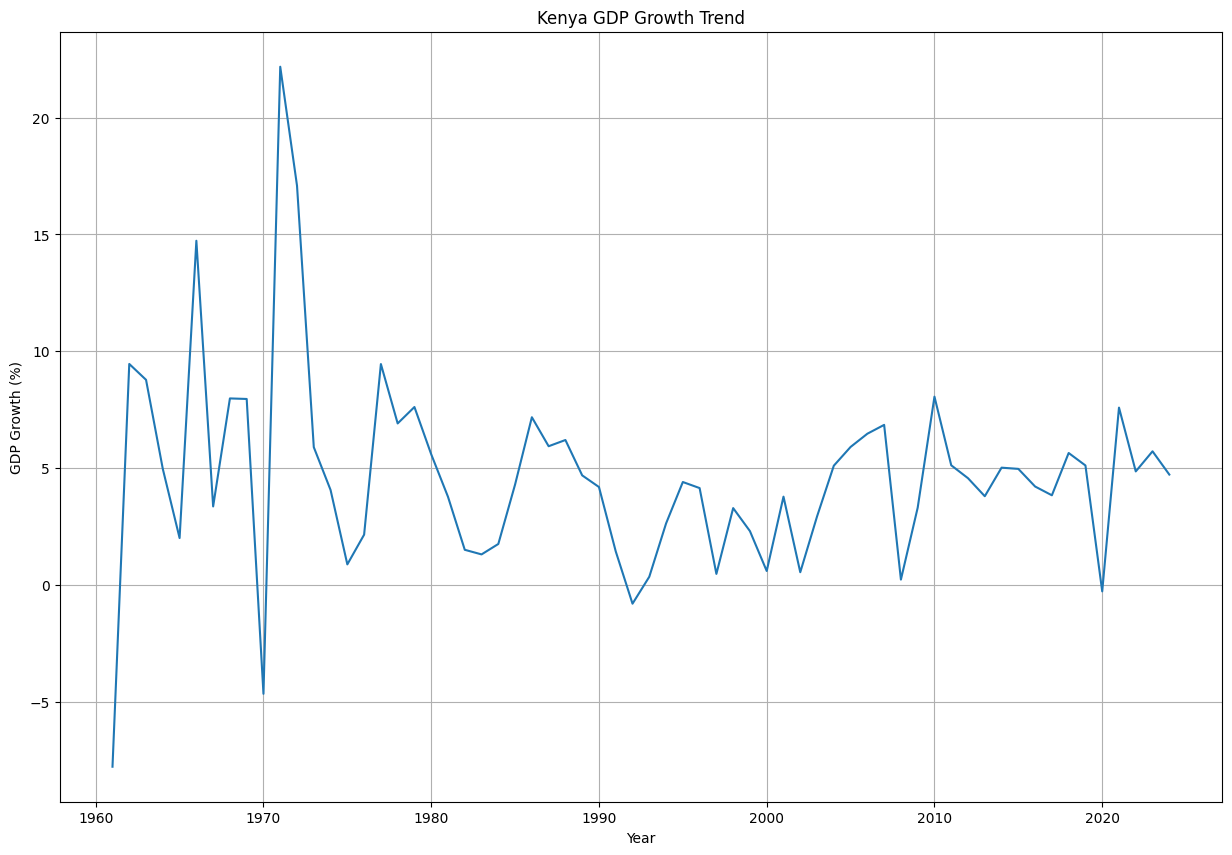

In [181]:
# ==========================================
# GDP GROWTH TREND
# ==========================================

gdp_growth = dashboard_df[
    dashboard_df["Indicator Name"] == 'GDP growth (annual %)'
]

plt.figure(figsize=(15,10))

plt.plot(
    gdp_growth["Year"],
    gdp_growth["Value"]
)

plt.title("Kenya GDP Growth Trend")
plt.xlabel("Year")
plt.ylabel("GDP Growth (%)")

plt.grid(True)

plt.show()

In [182]:
# ==========================================
# DATASET OVERVIEW
# ==========================================

dashboard_df.describe()

,Year,Value
count,435.000000,4.350000e+02
mean,1994.820690,3.887952e+09
std,18.266714,1.622633e+10
min,1960.000000,-7.774635e+00
25%,1979.500000,7.994170e+00
50%,1997.000000,5.823400e+01
75%,2010.000000,1.630998e+07
max,2024.000000,1.203396e+11


In [183]:
# ==========================================
# YEAR COVERAGE
# ==========================================

print("Minimum Year:", dashboard_df["Year"].min())
print("Maximum Year:", dashboard_df["Year"].max())

Minimum Year: 1960
Maximum Year: 2024


In [184]:
# ==========================================
# INDICATORS PER CATEGORY
# ==========================================

dashboard_df["Category"].value_counts()

Category
Economy           194
Health             65
Population         65
Education          49
Technology         31
Infrastructure     31
Name: count, dtype: int64

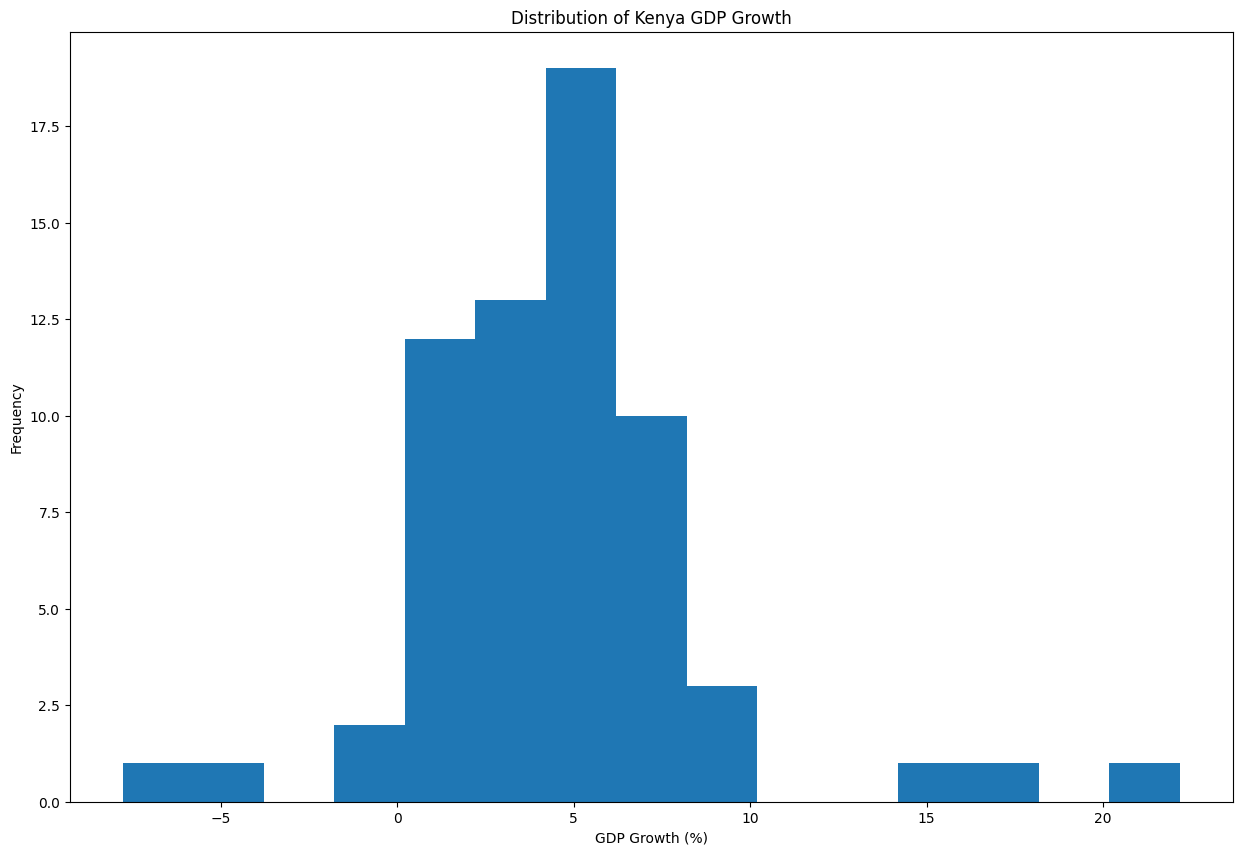

In [185]:
# ==========================================
# GDP GROWTH DISTRIBUTION
# ==========================================

gdp_growth = dashboard_df[
    dashboard_df["Indicator Name"] == 'GDP growth (annual %)'
]

plt.figure(figsize=(15,10))

plt.hist(gdp_growth["Value"], bins=15)

plt.title("Distribution of Kenya GDP Growth")
plt.xlabel("GDP Growth (%)")
plt.ylabel("Frequency")

plt.show()

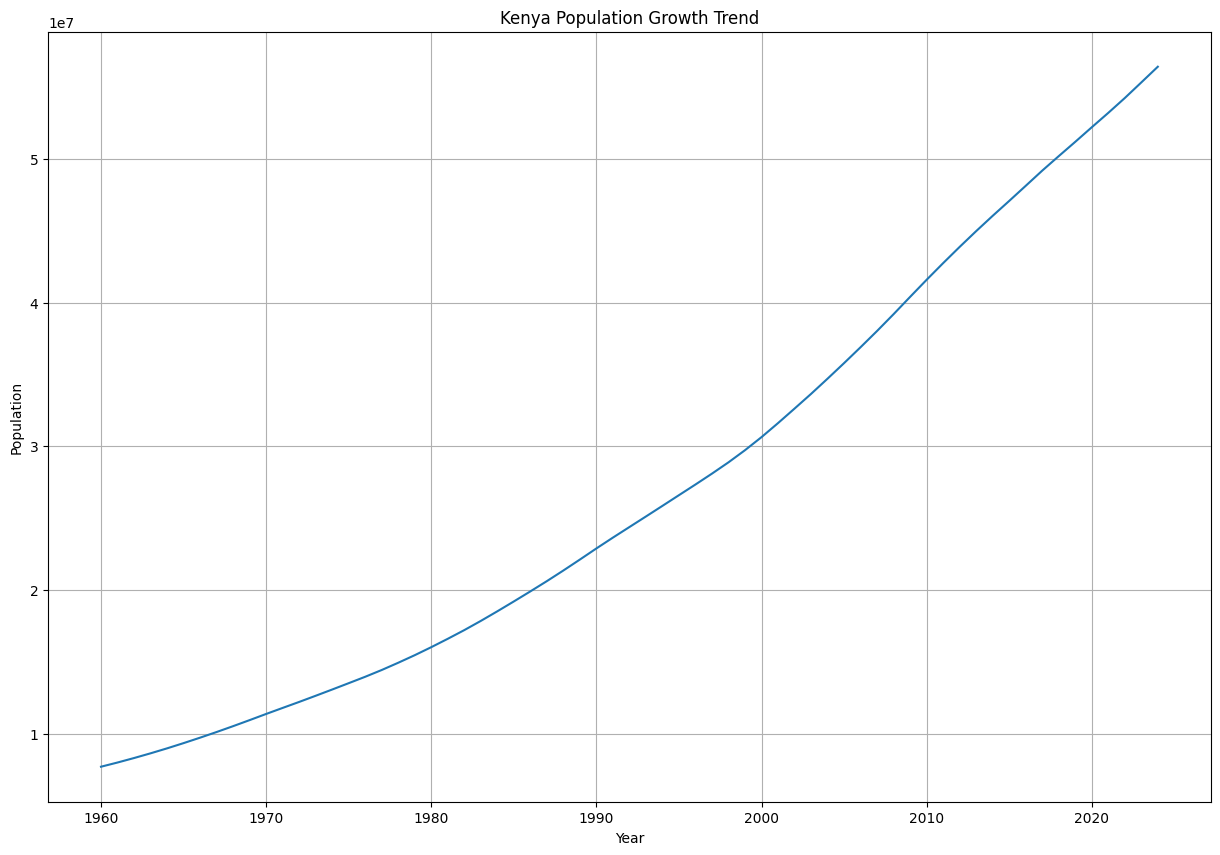

In [186]:
# ==========================================
# POPULATION TREND
# ==========================================

population_df = dashboard_df[
    dashboard_df["Indicator Name"] == 'Population, total'
]

plt.figure(figsize=(15,10))

plt.plot(
    population_df["Year"],
    population_df["Value"]
)

plt.title("Kenya Population Growth Trend")
plt.xlabel("Year")
plt.ylabel("Population")

plt.grid(True)

plt.show()

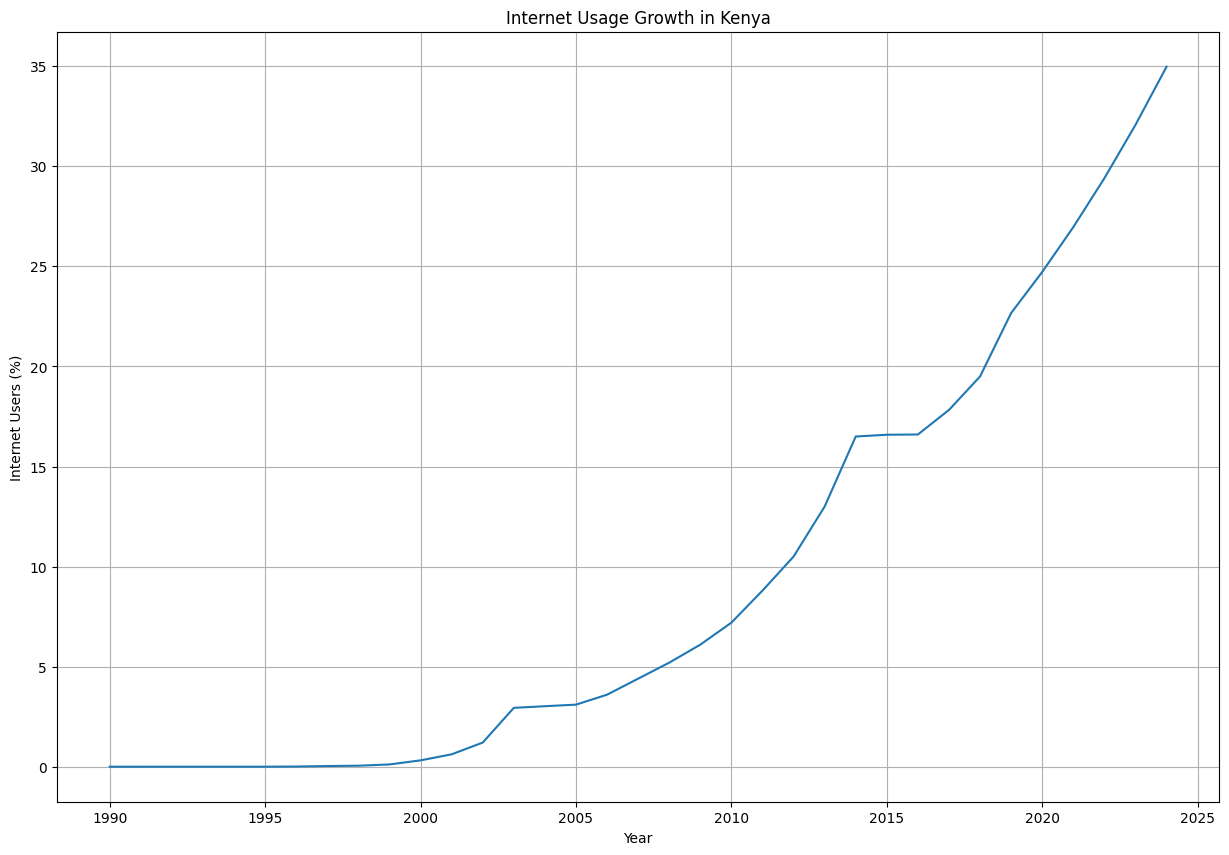

In [187]:
# ==========================================
# INTERNET USAGE TREND
# ==========================================

internet_df = dashboard_df[
    dashboard_df["Indicator Name"] == 'Individuals using the Internet (% of population)'
]

plt.figure(figsize=(15,10))

plt.plot(
    internet_df["Year"],
    internet_df["Value"]
)

plt.title("Internet Usage Growth in Kenya")
plt.xlabel("Year")
plt.ylabel("Internet Users (%)")

plt.grid(True)

plt.show()

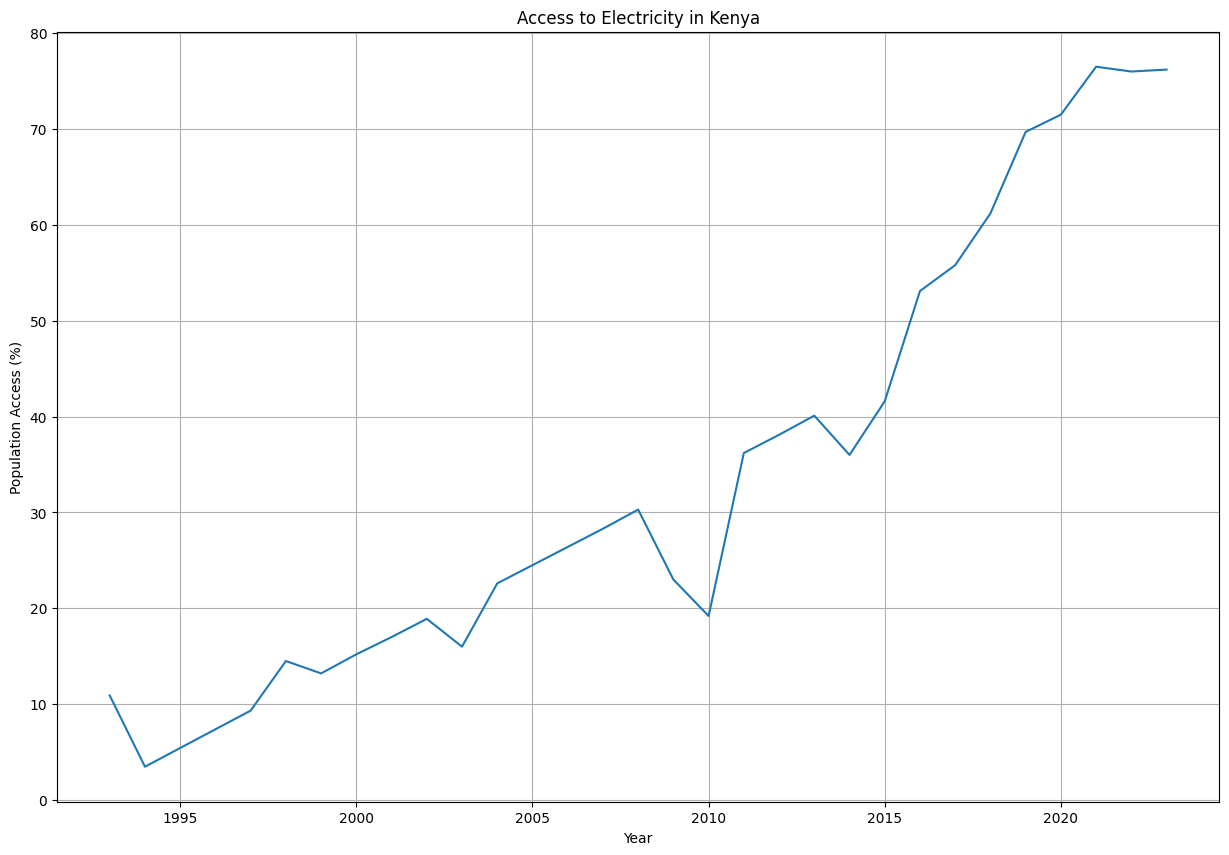

In [188]:
# ==========================================
# ELECTRICITY ACCESS TREND
# ==========================================

electricity_df = dashboard_df[
    dashboard_df["Indicator Name"] == 'Access to electricity (% of population)'
]

plt.figure(figsize=(15,10))

plt.plot(
    electricity_df["Year"],
    electricity_df["Value"]
)

plt.title("Access to Electricity in Kenya")
plt.xlabel("Year")
plt.ylabel("Population Access (%)")

plt.grid(True)

plt.show()

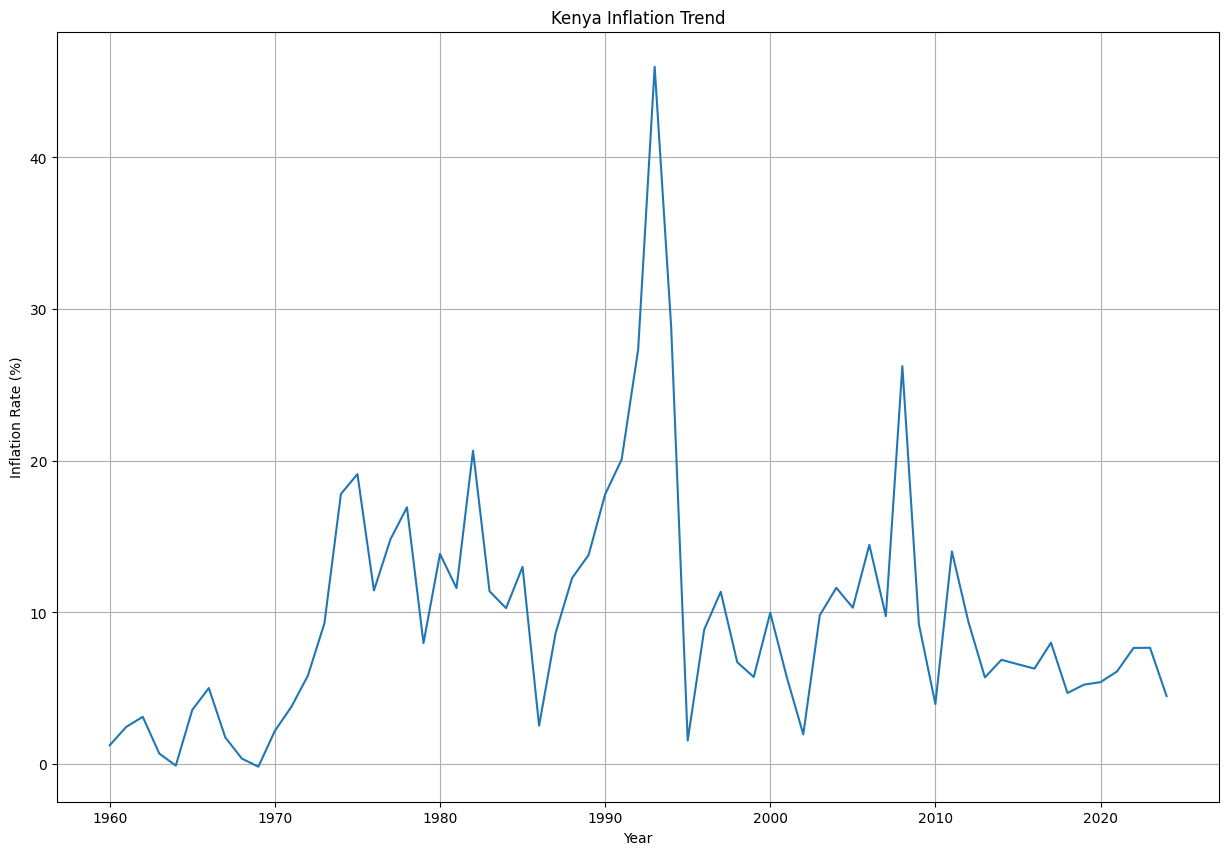

In [189]:
# ==========================================
# INFLATION TREND
# ==========================================

inflation_df = dashboard_df[
    dashboard_df["Indicator Name"] == 'Inflation, consumer prices (annual %)'
]

plt.figure(figsize=(15
                    ,10))

plt.plot(
    inflation_df["Year"],
    inflation_df["Value"]
)

plt.title("Kenya Inflation Trend")
plt.xlabel("Year")
plt.ylabel("Inflation Rate (%)")

plt.grid(True)

plt.show()

In [190]:
# ==========================================
# CREATE PIVOT TABLE
# ==========================================

pivot_df = dashboard_df.pivot_table(
    index="Year",
    columns="Indicator Name",
    values="Value"
)

pivot_df.head()

Indicator Name,Access to electricity (% of population),GDP (current US$),GDP growth (annual %),Individuals using the Internet (% of population),"Inflation, consumer prices (annual %)","Life expectancy at birth, total (years)","Population, total","School enrollment, primary (% gross)"
Year,,,,,,,,
1960,NaN,7.912655e+08,NaN,NaN,1.243781,48.477,7695307.0,NaN
1961,NaN,7.929595e+08,-7.774635,NaN,2.457002,49.330,7987770.0,NaN
1962,NaN,8.681114e+08,9.457359,NaN,3.117506,50.104,8299308.0,NaN
1963,NaN,9.265893e+08,8.778340,NaN,0.697674,50.758,8627971.0,NaN
1964,NaN,9.987593e+08,4.964467,NaN,-0.099305,51.323,8973535.0,NaN


In [191]:
# ==========================================
# CORRELATION MATRIX
# ==========================================

correlation_matrix = pivot_df.corr()

correlation_matrix

Indicator Name,Access to electricity (% of population),GDP (current US$),GDP growth (annual %),Individuals using the Internet (% of population),"Inflation, consumer prices (annual %)","Life expectancy at birth, total (years)","Population, total","School enrollment, primary (% gross)"
Indicator Name,,,,,,,,
Access to electricity (% of population),1.000000,0.972997,0.311081,0.971299,-0.302398,0.869687,0.953061,-0.131494
GDP (current US$),0.972997,1.000000,-0.015880,0.985831,-0.153913,0.708654,0.903992,-0.021284
GDP growth (annual %),0.311081,-0.015880,1.000000,0.277452,-0.263653,-0.034125,-0.109299,-0.292802
Individuals using the Internet (% of population),0.971299,0.985831,0.277452,1.000000,-0.291221,0.874081,0.947976,-0.134995
"Inflation, consumer prices (annual %)",-0.302398,-0.153913,-0.263653,-0.291221,1.000000,0.193455,0.007552,0.285194
"Life expectancy at birth, total (years)",0.869687,0.708654,-0.034125,0.874081,0.193455,1.000000,0.776112,0.497024
"Population, total",0.953061,0.903992,-0.109299,0.947976,0.007552,0.776112,1.000000,0.079585
"School enrollment, primary (% gross)",-0.131494,-0.021284,-0.292802,-0.134995,0.285194,0.497024,0.079585,1.000000


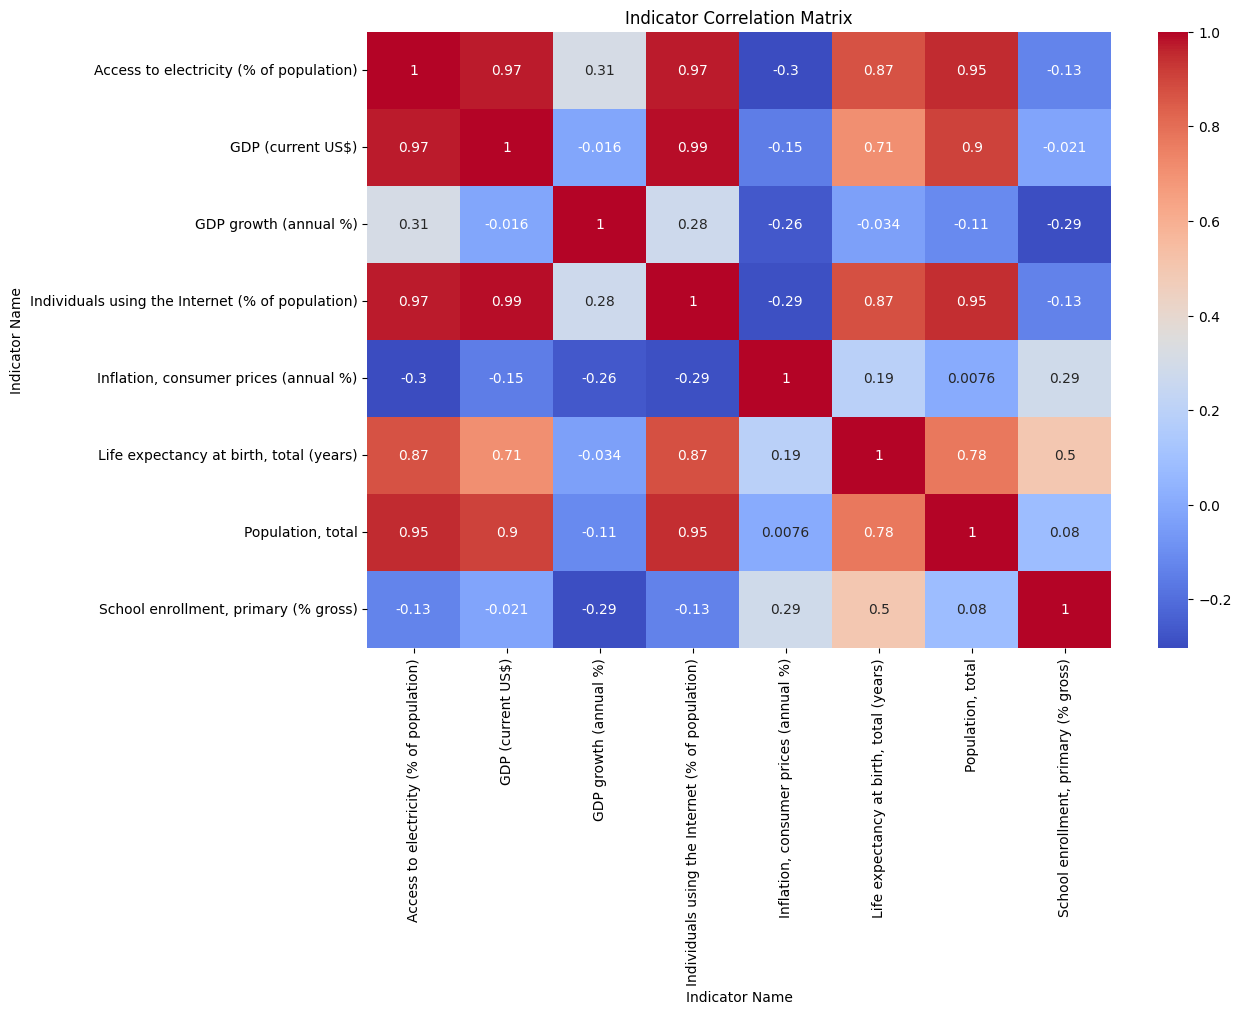

In [192]:
# ==========================================
# CORRELATION HEATMAP
# ==========================================

plt.figure(figsize=(12,8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm"
)

plt.title("Indicator Correlation Matrix")

plt.show()

In [193]:
# ==========================================
# SAVE FINAL ANALYTICS DATASET
# ==========================================

dashboard_df.to_csv(
    "kenya_analytics_dataset.csv",
    index=False
)

print("Analytics dataset saved successfully.")

Analytics dataset saved successfully.


In [194]:
# ==========================================
# CREATE LATEST KPI DATASET
# ==========================================

latest_kpi_df = dashboard_df.sort_values("Year").groupby(
    "Indicator Name"
).tail(1)

latest_kpi_df = latest_kpi_df[
    ["Indicator Name", "Category", "Year", "Value"]
].sort_values("Category")

latest_kpi_df

,Indicator Name,Category,Year,Value
96275,GDP growth (annual %),Economy,2024,4.724740e+00
96276,GDP (current US$),Economy,2024,1.203396e+11
96435,"Inflation, consumer prices (annual %)",Economy,2024,4.489789e+00
94536,"School enrollment, primary (% gross)",Education,2023,9.824835e+01
95148,"Life expectancy at birth, total (years)",Health,2024,6.383400e+01
93924,Access to electricity (% of population),Infrastructure,2023,7.620000e+01
95443,"Population, total",Population,2024,5.643294e+07
96155,Individuals using the Internet (% of population),Technology,2024,3.497623e+01


In [195]:
# ==========================================
# SAVE LATEST KPI DATASET
# ==========================================

latest_kpi_df.to_csv(
    "kenya_latest_kpi_dataset.csv",
    index=False
)

print("Latest KPI dataset saved successfully.")

Latest KPI dataset saved successfully.


In [196]:
# ==========================================
# EXPORT POWER BI READY FILES
# ==========================================

dashboard_df.to_csv("powerbi_kenya_indicator_trends.csv", index=False)
pivot_df.to_csv("powerbi_kenya_indicator_pivot.csv")
latest_kpi_df.to_csv("powerbi_kenya_latest_kpis.csv", index=False)

print("Power BI files exported successfully.")

Power BI files exported successfully.


KPI ENGINEERING & EXECUTIVE INSIGHTS

Right now:

you have cleaned data
structured datasets
trend analysis

Now we create:

executive metrics
intelligence signals
growth indicators
risk indicators
dashboard cards

These are what executives actually look at first.

In [197]:
# ==========================================
# GET LATEST YEAR FOR EACH INDICATOR
# ==========================================

latest_year_df = dashboard_df.loc[
    dashboard_df.groupby("Indicator Name")["Year"].idxmax()
]

latest_year_df

,Country Name,Country Code,Indicator Name,Indicator Code,Year,Value,Category
93924,Kenya,KEN,Access to electricity (% of population),EG.ELC.ACCS.ZS,2023,7.620000e+01,Infrastructure
96276,Kenya,KEN,GDP (current US$),NY.GDP.MKTP.CD,2024,1.203396e+11,Economy
96275,Kenya,KEN,GDP growth (annual %),NY.GDP.MKTP.KD.ZG,2024,4.724740e+00,Economy
96155,Kenya,KEN,Individuals using the Internet (% of population),IT.NET.USER.ZS,2024,3.497623e+01,Technology
96435,Kenya,KEN,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,2024,4.489789e+00,Economy
95148,Kenya,KEN,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,2024,6.383400e+01,Health
95443,Kenya,KEN,"Population, total",SP.POP.TOTL,2024,5.643294e+07,Population
94536,Kenya,KEN,"School enrollment, primary (% gross)",SE.PRM.ENRR,2023,9.824835e+01,Education


In [198]:
# ==========================================
# KPI SUMMARY TABLE
# ==========================================

kpi_summary = latest_year_df[
    ["Indicator Name", "Category", "Year", "Value"]
].copy()

kpi_summary

,Indicator Name,Category,Year,Value
93924,Access to electricity (% of population),Infrastructure,2023,7.620000e+01
96276,GDP (current US$),Economy,2024,1.203396e+11
96275,GDP growth (annual %),Economy,2024,4.724740e+00
96155,Individuals using the Internet (% of population),Technology,2024,3.497623e+01
96435,"Inflation, consumer prices (annual %)",Economy,2024,4.489789e+00
95148,"Life expectancy at birth, total (years)",Health,2024,6.383400e+01
95443,"Population, total",Population,2024,5.643294e+07
94536,"School enrollment, primary (% gross)",Education,2023,9.824835e+01


In [199]:
# ==========================================
# GDP PERFORMANCE CLASSIFICATION
# ==========================================

def classify_gdp_growth(value):

    if value >= 7:
        return "High Growth"

    elif value >= 4:
        return "Moderate Growth"

    elif value >= 1:
        return "Low Growth"

    else:
        return "Economic Stress"

gdp_df = dashboard_df[
    dashboard_df["Indicator Name"] == 'GDP growth (annual %)'
].copy()

gdp_df["Growth_Status"] = gdp_df["Value"].apply(classify_gdp_growth)

gdp_df.head()

,Country Name,Country Code,Indicator Name,Indicator Code,Year,Value,Category,Growth_Status
2657,Kenya,KEN,GDP growth (annual %),NY.GDP.MKTP.KD.ZG,1961,-7.774635,Economy,Economic Stress
4143,Kenya,KEN,GDP growth (annual %),NY.GDP.MKTP.KD.ZG,1962,9.457359,Economy,High Growth
5629,Kenya,KEN,GDP growth (annual %),NY.GDP.MKTP.KD.ZG,1963,8.778340,Economy,High Growth
7115,Kenya,KEN,GDP growth (annual %),NY.GDP.MKTP.KD.ZG,1964,4.964467,Economy,Moderate Growth
8601,Kenya,KEN,GDP growth (annual %),NY.GDP.MKTP.KD.ZG,1965,2.009094,Economy,Low Growth


In [200]:
# ==========================================
# INFLATION RISK CLASSIFICATION
# ==========================================

def inflation_risk(value):

    if value >= 10:
        return "High Inflation Risk"

    elif value >= 5:
        return "Moderate Inflation"

    else:
        return "Stable Inflation"

inflation_df = dashboard_df[
    dashboard_df["Indicator Name"] == 'Inflation, consumer prices (annual %)'
].copy()

inflation_df["Inflation_Status"] = inflation_df["Value"].apply(inflation_risk)

inflation_df.head()

,Country Name,Country Code,Indicator Name,Indicator Code,Year,Value,Category,Inflation_Status
1331,Kenya,KEN,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,1960,1.243781,Economy,Stable Inflation
2817,Kenya,KEN,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,1961,2.457002,Economy,Stable Inflation
4303,Kenya,KEN,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,1962,3.117506,Economy,Stable Inflation
5789,Kenya,KEN,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,1963,0.697674,Economy,Stable Inflation
7275,Kenya,KEN,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,1964,-0.099305,Economy,Stable Inflation


In [201]:
# ==========================================
# DIGITAL TRANSFORMATION STATUS
# ==========================================

internet_df = dashboard_df[
    dashboard_df["Indicator Name"] == 'Individuals using the Internet (% of population)'
].copy()

def digital_status(value):

    if value >= 70:
        return "Highly Connected"

    elif value >= 40:
        return "Growing Digital Economy"

    else:
        return "Emerging Connectivity"

internet_df["Digital_Status"] = internet_df["Value"].apply(digital_status)

internet_df.head()

,Country Name,Country Code,Indicator Name,Indicator Code,Year,Value,Category,Digital_Status
45631,Kenya,KEN,Individuals using the Internet (% of population),IT.NET.USER.ZS,1990,0.000000,Technology,Emerging Connectivity
53061,Kenya,KEN,Individuals using the Internet (% of population),IT.NET.USER.ZS,1995,0.000727,Technology,Emerging Connectivity
54547,Kenya,KEN,Individuals using the Internet (% of population),IT.NET.USER.ZS,1996,0.008840,Technology,Emerging Connectivity
56033,Kenya,KEN,Individuals using the Internet (% of population),IT.NET.USER.ZS,1997,0.034400,Technology,Emerging Connectivity
57519,Kenya,KEN,Individuals using the Internet (% of population),IT.NET.USER.ZS,1998,0.050300,Technology,Emerging Connectivity


In [202]:
# ==========================================
# ELECTRICITY ACCESS STATUS
# ==========================================

electricity_df = dashboard_df[
    dashboard_df["Indicator Name"] == 'Access to electricity (% of population)'
].copy()

def electricity_status(value):

    if value >= 80:
        return "High Infrastructure Access"

    elif value >= 50:
        return "Moderate Infrastructure Access"

    else:
        return "Infrastructure Gap"

electricity_df["Infrastructure_Status"] = electricity_df["Value"].apply(electricity_status)

electricity_df.head()

,Country Name,Country Code,Indicator Name,Indicator Code,Year,Value,Category,Infrastructure_Status
49344,Kenya,KEN,Access to electricity (% of population),EG.ELC.ACCS.ZS,1993,10.900000,Infrastructure,Infrastructure Gap
50830,Kenya,KEN,Access to electricity (% of population),EG.ELC.ACCS.ZS,1994,3.473437,Infrastructure,Infrastructure Gap
52316,Kenya,KEN,Access to electricity (% of population),EG.ELC.ACCS.ZS,1995,5.427343,Infrastructure,Infrastructure Gap
53802,Kenya,KEN,Access to electricity (% of population),EG.ELC.ACCS.ZS,1996,7.378531,Infrastructure,Infrastructure Gap
55288,Kenya,KEN,Access to electricity (% of population),EG.ELC.ACCS.ZS,1997,9.326318,Infrastructure,Infrastructure Gap


In [203]:
# ==========================================
# CREATE DEVELOPMENT SCORE
# ==========================================

latest_metrics = latest_year_df.copy()

latest_metrics["Normalized_Value"] = (
    latest_metrics["Value"] - latest_metrics["Value"].min()
) / (
    latest_metrics["Value"].max() - latest_metrics["Value"].min()
)

development_score = latest_metrics["Normalized_Value"].mean() * 100

print("Kenya National Development Score:", round(development_score, 2))

Kenya National Development Score: 12.51


In [204]:
# ==========================================
# SAVE KPI TABLES
# ==========================================

gdp_df.to_csv(
    "gdp_growth_status.csv",
    index=False
)

inflation_df.to_csv(
    "inflation_risk_status.csv",
    index=False
)

internet_df.to_csv(
    "digital_transformation_status.csv",
    index=False
)

electricity_df.to_csv(
    "infrastructure_status.csv",
    index=False
)

print("Executive KPI datasets saved successfully.")

Executive KPI datasets saved successfully.


In [205]:
# ==========================================
# FILTER ECONOMIC INDICATORS
# ==========================================

economic_indicators = [

    'GDP growth (annual %)',
    'GDP (current US$)',
    'Inflation, consumer prices (annual %)',
    'Unemployment, total (% of total labor force)'

]

economic_df = dashboard_df[
    dashboard_df["Indicator Name"].isin(economic_indicators)
].copy()

print("Economic Dataset Shape:", economic_df.shape)

economic_df.head()

Economic Dataset Shape: (194, 7)


,Country Name,Country Code,Indicator Name,Indicator Code,Year,Value,Category
1172,Kenya,KEN,GDP (current US$),NY.GDP.MKTP.CD,1960,7.912655e+08,Economy
1331,Kenya,KEN,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,1960,1.243781e+00,Economy
2657,Kenya,KEN,GDP growth (annual %),NY.GDP.MKTP.KD.ZG,1961,-7.774635e+00,Economy
2658,Kenya,KEN,GDP (current US$),NY.GDP.MKTP.CD,1961,7.929595e+08,Economy
2817,Kenya,KEN,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,1961,2.457002e+00,Economy


In [206]:
# ==========================================
# CHECK MISSING VALUES
# ==========================================

economic_df.isnull().sum()

Country Name      0
Country Code      0
Indicator Name    0
Indicator Code    0
Year              0
Value             0
Category          0
dtype: int64

In [207]:
# ==========================================
# COUNT ECONOMIC RECORDS
# ==========================================

economic_df["Indicator Name"].value_counts()

Indicator Name
GDP (current US$)                        65
Inflation, consumer prices (annual %)    65
GDP growth (annual %)                    64
Name: count, dtype: int64

In [208]:
# ==========================================
# GDP GROWTH SUMMARY
# ==========================================

gdp_growth_df = economic_df[
    economic_df["Indicator Name"] == 'GDP growth (annual %)'
]

gdp_growth_df["Value"].describe()

count    64.000000
mean      4.631795
std       4.329843
min      -7.774635
25%       2.267533
50%       4.487448
75%       6.003627
max      22.173892
Name: Value, dtype: float64

In [209]:
# ==========================================
# INFLATION SUMMARY
# ==========================================

inflation_df = economic_df[
    economic_df["Indicator Name"] == 'Inflation, consumer prices (annual %)'
]

inflation_df["Value"].describe()

count    65.000000
mean      9.702477
std       7.980163
min      -0.171501
25%       4.689806
50%       8.005650
75%      12.264963
max      45.978881
Name: Value, dtype: float64

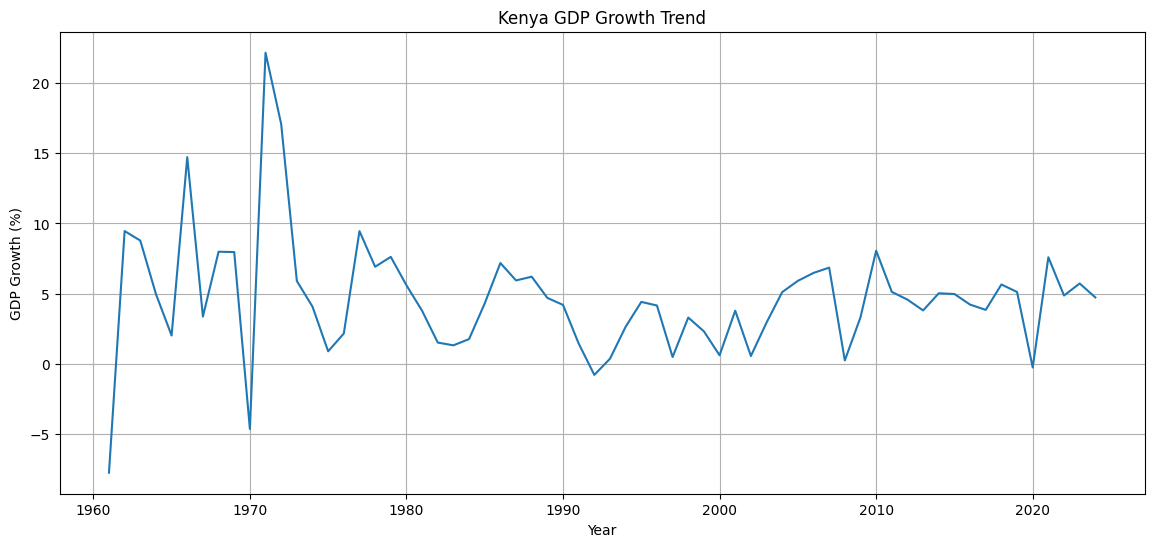

In [210]:
# ==========================================
# GDP GROWTH TREND
# ==========================================

plt.figure(figsize=(14,6))

plt.plot(
    gdp_growth_df["Year"],
    gdp_growth_df["Value"]
)

plt.title("Kenya GDP Growth Trend")
plt.xlabel("Year")
plt.ylabel("GDP Growth (%)")

plt.grid(True)

plt.show()

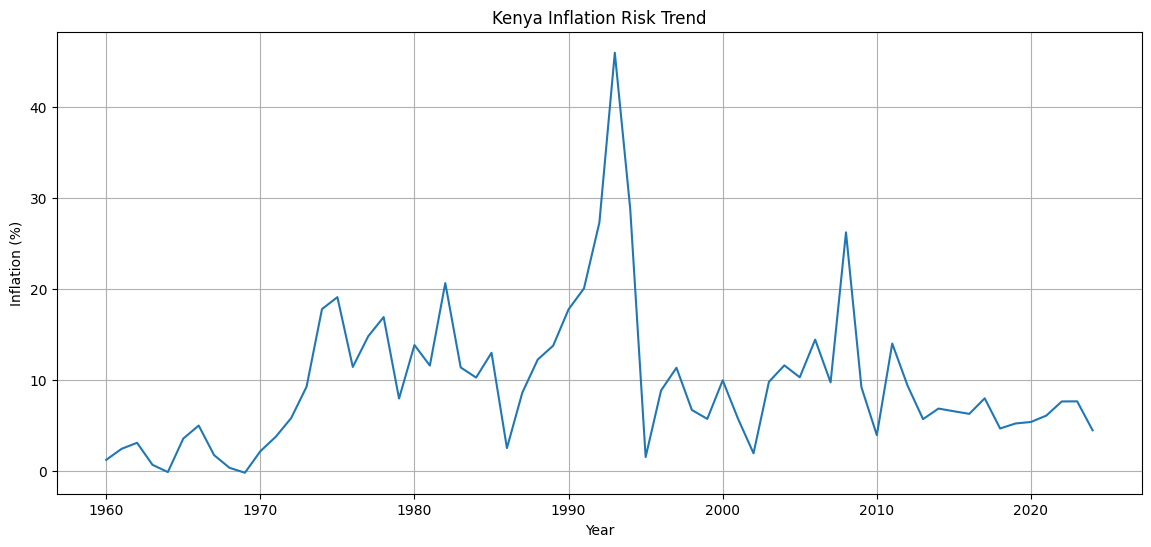

In [211]:
# ==========================================
# INFLATION TREND
# ==========================================

plt.figure(figsize=(14,6))

plt.plot(
    inflation_df["Year"],
    inflation_df["Value"]
)

plt.title("Kenya Inflation Risk Trend")
plt.xlabel("Year")
plt.ylabel("Inflation (%)")

plt.grid(True)

plt.show()

In [212]:
# ==========================================
# GDP VS INFLATION
# ==========================================

gdp_compare = gdp_growth_df[["Year", "Value"]].rename(
    columns={"Value":"GDP Growth"}
)

inflation_compare = inflation_df[["Year", "Value"]].rename(
    columns={"Value":"Inflation"}
)

comparison_df = pd.merge(
    gdp_compare,
    inflation_compare,
    on="Year",
    how="inner"
)

comparison_df.head()

,Year,GDP Growth,Inflation
0,1961,-7.774635,2.457002
1,1962,9.457359,3.117506
2,1963,8.778340,0.697674
3,1964,4.964467,-0.099305
4,1965,2.009094,3.578529


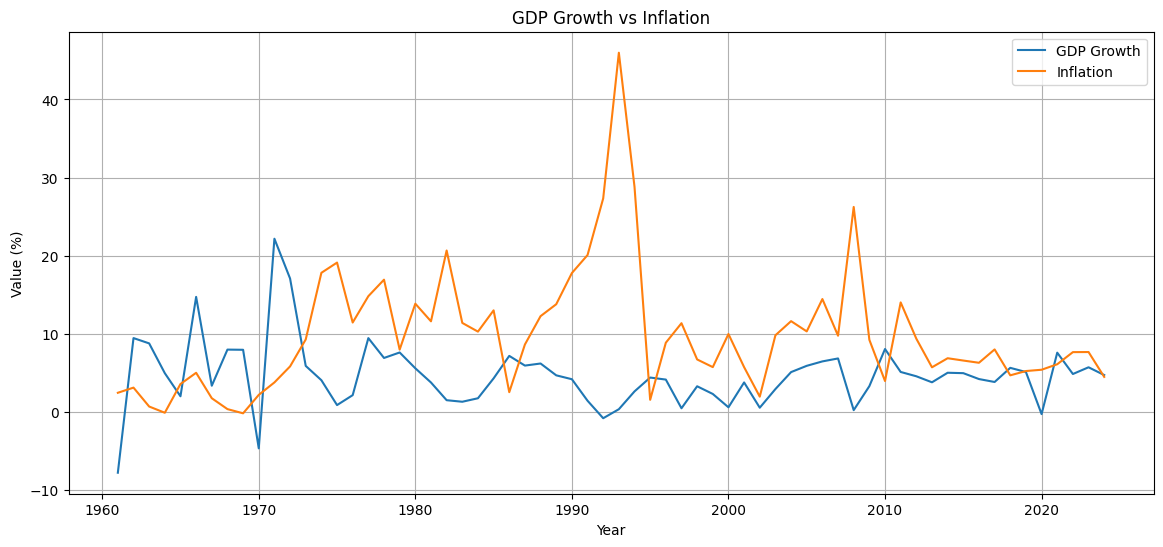

In [213]:
# ==========================================
# GDP VS INFLATION VISUAL
# ==========================================

plt.figure(figsize=(14,6))

plt.plot(
    comparison_df["Year"],
    comparison_df["GDP Growth"],
    label="GDP Growth"
)

plt.plot(
    comparison_df["Year"],
    comparison_df["Inflation"],
    label="Inflation"
)

plt.title("GDP Growth vs Inflation")
plt.xlabel("Year")
plt.ylabel("Value (%)")

plt.legend()

plt.grid(True)

plt.show()

In [214]:
# ==========================================
# ECONOMIC RISK STATUS
# ==========================================

def economic_risk(gdp, inflation):

    if gdp < 2 and inflation > 8:
        return "High Economic Risk"

    elif gdp < 4:
        return "Moderate Risk"

    else:
        return "Stable Growth"

comparison_df["Economic_Risk"] = comparison_df.apply(
    lambda row: economic_risk(
        row["GDP Growth"],
        row["Inflation"]
    ),
    axis=1
)

comparison_df.head()

,Year,GDP Growth,Inflation,Economic_Risk
0,1961,-7.774635,2.457002,Moderate Risk
1,1962,9.457359,3.117506,Stable Growth
2,1963,8.778340,0.697674,Stable Growth
3,1964,4.964467,-0.099305,Stable Growth
4,1965,2.009094,3.578529,Moderate Risk


In [215]:
# ==========================================
# SAVE PAGE 2 DATASETS
# ==========================================

economic_df.to_csv(
    "economic_performance_dataset.csv",
    index=False
)

comparison_df.to_csv(
    "gdp_vs_inflation_dataset.csv",
    index=False
)

print("Economic Intelligence datasets saved successfully.")

Economic Intelligence datasets saved successfully.


In [216]:
# ==========================================
# LATEST ECONOMIC KPI VALUES
# ==========================================

latest_economic_kpis = economic_df.sort_values("Year").groupby(
    "Indicator Name"
).tail(1)

latest_economic_kpis = latest_economic_kpis[
    ["Indicator Name", "Year", "Value"]
].sort_values("Indicator Name")

latest_economic_kpis

,Indicator Name,Year,Value
96276,GDP (current US$),2024,1.203396e+11
96275,GDP growth (annual %),2024,4.724740e+00
96435,"Inflation, consumer prices (annual %)",2024,4.489789e+00


In [217]:
# ==========================================
# ECONOMIC RISK SCORE
# ==========================================

comparison_df["Economic_Risk_Score"] = np.where(
    (comparison_df["GDP Growth"] < 2) & (comparison_df["Inflation"] > 8),
    3,
    np.where(
        (comparison_df["GDP Growth"] < 4) | (comparison_df["Inflation"] > 8),
        2,
        1
    )
)

comparison_df.head()

,Year,GDP Growth,Inflation,Economic_Risk,Economic_Risk_Score
0,1961,-7.774635,2.457002,Moderate Risk,2
1,1962,9.457359,3.117506,Stable Growth,1
2,1963,8.778340,0.697674,Stable Growth,1
3,1964,4.964467,-0.099305,Stable Growth,1
4,1965,2.009094,3.578529,Moderate Risk,2


In [218]:
# ==========================================
# ECONOMIC RISK LABEL
# ==========================================

risk_map = {
    1: "Stable Growth",
    2: "Moderate Risk",
    3: "High Economic Risk"
}

comparison_df["Economic_Risk_Label"] = comparison_df["Economic_Risk_Score"].map(risk_map)

comparison_df.head()

,Year,GDP Growth,Inflation,Economic_Risk,Economic_Risk_Score,Economic_Risk_Label
0,1961,-7.774635,2.457002,Moderate Risk,2,Moderate Risk
1,1962,9.457359,3.117506,Stable Growth,1,Stable Growth
2,1963,8.778340,0.697674,Stable Growth,1,Stable Growth
3,1964,4.964467,-0.099305,Stable Growth,1,Stable Growth
4,1965,2.009094,3.578529,Moderate Risk,2,Moderate Risk


In [219]:
# ==========================================
# COUNT ECONOMIC RISK YEARS
# ==========================================

risk_years_summary = comparison_df["Economic_Risk_Label"].value_counts().reset_index()

risk_years_summary.columns = ["Economic Risk Level", "Number of Years"]

risk_years_summary

,Economic Risk Level,Number of Years
0,Moderate Risk,33
1,Stable Growth,21
2,High Economic Risk,10


In [220]:
# ==========================================
# SAVE FINAL PAGE 2 OUTPUTS
# ==========================================

latest_economic_kpis.to_csv(
    "page2_latest_economic_kpis.csv",
    index=False
)

comparison_df.to_csv(
    "page2_gdp_inflation_risk_dataset.csv",
    index=False
)

risk_years_summary.to_csv(
    "page2_economic_risk_summary.csv",
    index=False
)

print("Page 2 economic performance files saved successfully.")

Page 2 economic performance files saved successfully.


In [221]:
# ==========================================
# UPDATE ECONOMIC INDICATORS WITH CORRECT
# UNEMPLOYMENT INDICATOR
# ==========================================

economic_indicators = [

    'GDP growth (annual %)',
    'GDP (current US$)',
    'Inflation, consumer prices (annual %)',
    'Unemployment, total (% of total labor force) (modeled ILO estimate)'

]

# Recreate economic dataframe
economic_df = long_clean_df[
    long_clean_df["Indicator Name"].isin(economic_indicators)
].copy()

# Check indicators loaded
print(economic_df["Indicator Name"].unique())

# Save updated dataset
economic_df.to_csv(
    "economic_performance_dataset.csv",
    index=False
)

print("Updated economic dataset exported successfully.")

<StringArray>
[                                                  'GDP (current US$)',
                               'Inflation, consumer prices (annual %)',
                                               'GDP growth (annual %)',
 'Unemployment, total (% of total labor force) (modeled ILO estimate)']
Length: 4, dtype: str
Updated economic dataset exported successfully.


In [222]:
# ==========================================
# SOCIAL DEVELOPMENT DATASET
# ==========================================

social_indicators = [

    'Life expectancy at birth, total (years)',
    'School enrollment, primary (% gross)',
    'Population growth (annual %)',
    'Urban population (% of total population)'

]

social_df = long_clean_df[
    long_clean_df["Indicator Name"].isin(social_indicators)
].copy()

print("Social Dataset Shape:", social_df.shape)

social_df.head()

Social Dataset Shape: (243, 6)


,Country Name,Country Code,Indicator Name,Indicator Code,Year,Value
44,Kenya,KEN,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,1960,48.477000
335,Kenya,KEN,Urban population (% of total population),SP.URB.TOTL.IN.ZS,1960,8.233521
1530,Kenya,KEN,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,1961,49.330000
1821,Kenya,KEN,Urban population (% of total population),SP.URB.TOTL.IN.ZS,1961,8.435939
2175,Kenya,KEN,Population growth (annual %),SP.POP.GROW,1961,3.730096


In [223]:
social_df["Indicator Name"].value_counts()

Indicator Name
Life expectancy at birth, total (years)     65
Urban population (% of total population)    65
Population growth (annual %)                64
School enrollment, primary (% gross)        49
Name: count, dtype: int64

In [224]:
# ==========================================
# LATEST SOCIAL KPIs
# ==========================================

latest_social_kpis = (
    social_df
    .sort_values("Year")
    .groupby("Indicator Name")
    .tail(1)
)

latest_social_kpis = latest_social_kpis[
    ["Indicator Name", "Year", "Value"]
]

latest_social_kpis

,Indicator Name,Year,Value
94536,"School enrollment, primary (% gross)",2023,98.248348
95148,"Life expectancy at birth, total (years)",2024,63.834000
95439,Urban population (% of total population),2024,31.893783
95793,Population growth (annual %),2024,1.957514


In [225]:
life_df = social_df[
    social_df["Indicator Name"] ==
    "Life expectancy at birth, total (years)"
]

life_df["Value"].describe()

count    65.000000
mean     57.862323
std       3.765119
min      48.477000
25%      55.575000
50%      58.234000
75%      60.818000
max      63.834000
Name: Value, dtype: float64

In [226]:
population_growth_df = social_df[
    social_df["Indicator Name"] ==
    "Population growth (annual %)"
]

population_growth_df["Value"].describe()

count    64.000000
mean      3.113191
std       0.610033
min       1.900409
25%       2.757877
50%       3.141278
75%       3.575751
max       3.986045
Name: Value, dtype: float64

In [227]:
# ==========================================
# SOCIAL DEVELOPMENT SCORE
# ==========================================

latest_year = social_df["Year"].max()

latest_social = social_df[
    social_df["Year"] == latest_year
].copy()

social_score = (
    latest_social["Value"].mean()
)

print("Social Development Score:", round(social_score,2))

Social Development Score: 32.56


In [228]:
life_expectancy_dataset = life_df[
    ["Year","Value"]
].copy()

life_expectancy_dataset.rename(
    columns={"Value":"Life_Expectancy"},
    inplace=True
)

life_expectancy_dataset.head()

,Year,Life_Expectancy
44,1960,48.477
1530,1961,49.330
3016,1962,50.104
4502,1963,50.758
5988,1964,51.323


In [229]:
population_growth_dataset = population_growth_df[
    ["Year","Value"]
].copy()

population_growth_dataset.rename(
    columns={"Value":"Population_Growth"},
    inplace=True
)

population_growth_dataset.head()

,Year,Population_Growth
2175,1961,3.730096
3661,1962,3.826052
5147,1963,3.883723
6633,1964,3.927032
8119,1965,3.982076


In [230]:
# ==========================================
# SAVE PAGE 3 FILES
# ==========================================

social_df.to_csv(
    "social_development_dataset.csv",
    index=False
)

latest_social_kpis.to_csv(
    "page3_latest_social_kpis.csv",
    index=False
)

life_expectancy_dataset.to_csv(
    "life_expectancy_dataset.csv",
    index=False
)

population_growth_dataset.to_csv(
    "population_growth_dataset.csv",
    index=False
)

print("Page 3 datasets saved successfully.")

Page 3 datasets saved successfully.


In [231]:
social_df["Indicator Name"].value_counts()

Indicator Name
Life expectancy at birth, total (years)     65
Urban population (% of total population)    65
Population growth (annual %)                64
School enrollment, primary (% gross)        49
Name: count, dtype: int64

In [232]:
latest_social_kpis

,Indicator Name,Year,Value
94536,"School enrollment, primary (% gross)",2023,98.248348
95148,"Life expectancy at birth, total (years)",2024,63.834000
95439,Urban population (% of total population),2024,31.893783
95793,Population growth (annual %),2024,1.957514


In [233]:
print("Social Development Score:", round(social_score,2))

Social Development Score: 32.56


In [234]:
# ==========================================
# URBAN POPULATION DATASET
# ==========================================

urban_df = social_df[
    social_df["Indicator Name"] ==
    "Urban population (% of total population)"
]

urban_population_dataset = urban_df[
    ["Year","Value"]
].copy()

urban_population_dataset.rename(
    columns={"Value":"Urban_Population"},
    inplace=True
)

urban_population_dataset.head()

,Year,Urban_Population
335,1960,8.233521
1821,1961,8.435939
3307,1962,8.634079
4793,1963,8.815345
6279,1964,8.972303


In [235]:
urban_population_dataset.to_csv(
    "urban_population_dataset.csv",
    index=False
)

In [236]:
social_indicator_coverage = (
    latest_social_kpis[["Indicator Name","Value"]]
    .copy()
)

social_indicator_coverage.to_csv(
    "social_indicator_coverage.csv",
    index=False
)

In [237]:
# ==========================================
# PAGE 4: INFRASTRUCTURE & DIGITAL DATASET
# ==========================================

digital_infra_indicators = [

    'Individuals using the Internet (% of population)',
    'Access to electricity (% of population)',
    'Mobile cellular subscriptions (per 100 people)',
    'Urban population (% of total population)'

]

digital_infra_df = long_clean_df[
    long_clean_df["Indicator Name"].isin(digital_infra_indicators)
].copy()

print("Digital Infrastructure Dataset Shape:", digital_infra_df.shape)

digital_infra_df.head()

Digital Infrastructure Dataset Shape: (180, 6)


,Country Name,Country Code,Indicator Name,Indicator Code,Year,Value
335,Kenya,KEN,Urban population (% of total population),SP.URB.TOTL.IN.ZS,1960,8.233521
554,Kenya,KEN,Mobile cellular subscriptions (per 100 people),IT.CEL.SETS.P2,1960,0.000000
1821,Kenya,KEN,Urban population (% of total population),SP.URB.TOTL.IN.ZS,1961,8.435939
3307,Kenya,KEN,Urban population (% of total population),SP.URB.TOTL.IN.ZS,1962,8.634079
4793,Kenya,KEN,Urban population (% of total population),SP.URB.TOTL.IN.ZS,1963,8.815345


In [238]:
# ==========================================
# CHECK PAGE 4 INDICATOR COVERAGE
# ==========================================

digital_infra_df["Indicator Name"].value_counts()

Indicator Name
Urban population (% of total population)            65
Mobile cellular subscriptions (per 100 people)      53
Individuals using the Internet (% of population)    31
Access to electricity (% of population)             31
Name: count, dtype: int64

In [239]:
# ==========================================
# LATEST PAGE 4 KPI VALUES
# ==========================================

latest_digital_infra_kpis = (
    digital_infra_df
    .sort_values("Year")
    .groupby("Indicator Name")
    .tail(1)
)

latest_digital_infra_kpis = latest_digital_infra_kpis[
    ["Indicator Name", "Year", "Value"]
].sort_values("Indicator Name")

latest_digital_infra_kpis

,Indicator Name,Year,Value
93924,Access to electricity (% of population),2023,76.200000
96155,Individuals using the Internet (% of population),2024,34.976225
95658,Mobile cellular subscriptions (per 100 people),2024,126.477706
95439,Urban population (% of total population),2024,31.893783


In [240]:
# ==========================================
# INTERNET USAGE DATASET
# ==========================================

internet_usage_df = digital_infra_df[
    digital_infra_df["Indicator Name"] ==
    "Individuals using the Internet (% of population)"
]

internet_usage_dataset = internet_usage_df[
    ["Year", "Value"]
].copy()

internet_usage_dataset.rename(
    columns={"Value": "Internet_Usage"},
    inplace=True
)

internet_usage_dataset.head()

,Year,Internet_Usage
45631,1990,0.000000
53061,1995,0.000727
54547,1996,0.008840
56033,1997,0.034400
57519,1998,0.050300


In [241]:
# ==========================================
# ELECTRICITY ACCESS DATASET
# ==========================================

electricity_access_df = digital_infra_df[
    digital_infra_df["Indicator Name"] ==
    "Access to electricity (% of population)"
]

electricity_access_dataset = electricity_access_df[
    ["Year", "Value"]
].copy()

electricity_access_dataset.rename(
    columns={"Value": "Electricity_Access"},
    inplace=True
)

electricity_access_dataset.head()

,Year,Electricity_Access
49344,1993,10.900000
50830,1994,3.473437
52316,1995,5.427343
53802,1996,7.378531
55288,1997,9.326318


In [242]:
# ==========================================
# MOBILE SUBSCRIPTIONS DATASET
# ==========================================

mobile_subscription_df = digital_infra_df[
    digital_infra_df["Indicator Name"] ==
    "Mobile cellular subscriptions (per 100 people)"
]

mobile_subscription_dataset = mobile_subscription_df[
    ["Year", "Value"]
].copy()

mobile_subscription_dataset.rename(
    columns={"Value": "Mobile_Subscriptions"},
    inplace=True
)

mobile_subscription_dataset.head()

,Year,Mobile_Subscriptions
554,1960,0.0
7984,1965,0.0
15414,1970,0.0
22844,1975,0.0
24330,1976,0.0


In [243]:
# ==========================================
# URBAN POPULATION DATASET
# ==========================================

urban_infra_df = digital_infra_df[
    digital_infra_df["Indicator Name"] ==
    "Urban population (% of total population)"
]

urban_infra_dataset = urban_infra_df[
    ["Year", "Value"]
].copy()

urban_infra_dataset.rename(
    columns={"Value": "Urban_Population"},
    inplace=True
)

urban_infra_dataset.head()

,Year,Urban_Population
335,1960,8.233521
1821,1961,8.435939
3307,1962,8.634079
4793,1963,8.815345
6279,1964,8.972303


In [244]:
# ==========================================
# INTERNET VS ELECTRICITY DATASET
# ==========================================

internet_compare = internet_usage_dataset.rename(
    columns={"Internet_Usage": "Internet Usage"}
)

electricity_compare = electricity_access_dataset.rename(
    columns={"Electricity_Access": "Electricity Access"}
)

internet_electricity_df = pd.merge(
    internet_compare,
    electricity_compare,
    on="Year",
    how="inner"
)

internet_electricity_df.head()

,Year,Internet Usage,Electricity Access
0,1995,0.000727,5.427343
1,1996,0.008840,7.378531
2,1997,0.034400,9.326318
3,1998,0.050300,14.500000
4,1999,0.114000,13.208892


In [245]:
# ==========================================
# DIGITAL INFRASTRUCTURE SCORE
# ==========================================

latest_year = digital_infra_df["Year"].max()

latest_digital = digital_infra_df[
    digital_infra_df["Year"] == latest_year
].copy()

score_values = {}

for indicator in digital_infra_indicators:
    value = latest_digital.loc[
        latest_digital["Indicator Name"] == indicator,
        "Value"
    ]

    if len(value) > 0:
        score_values[indicator] = value.iloc[0]

internet_score = score_values.get(
    'Individuals using the Internet (% of population)', 0
) / 100

electricity_score = score_values.get(
    'Access to electricity (% of population)', 0
) / 100

mobile_score = min(
    score_values.get('Mobile cellular subscriptions (per 100 people)', 0),
    100
) / 100

urban_score = score_values.get(
    'Urban population (% of total population)', 0
) / 100

digital_infrastructure_score = (
    internet_score * 0.30 +
    electricity_score * 0.30 +
    mobile_score * 0.25 +
    urban_score * 0.15
) * 100

print("Digital Infrastructure Score:", round(digital_infrastructure_score, 2))

Digital Infrastructure Score: 40.28


In [247]:
# ==========================================
# SAVE PAGE 4 DATASETS
# ==========================================

digital_infra_df.to_csv(
    "digital_infrastructure_dataset.csv",
    index=False
)

latest_digital_infra_kpis.to_csv(
    "page4_latest_digital_infra_kpis.csv",
    index=False
)

internet_usage_dataset.to_csv(
    "internet_usage_dataset.csv",
    index=False
)

electricity_access_dataset.to_csv(
    "electricity_access_dataset.csv",
    index=False
)

mobile_subscription_dataset.to_csv(
    "mobile_subscription_dataset.csv",
    index=False
)

urban_infra_dataset.to_csv(
    "page4_urban_population_dataset.csv",
    index=False
)

internet_electricity_df.to_csv(
    "internet_vs_electricity_dataset.csv",
    index=False
)

print("Page 4 Digital Infrastructure datasets saved successfully.")

Page 4 Digital Infrastructure datasets saved successfully.


In [248]:
digital_infra_df["Indicator Name"].value_counts()

Indicator Name
Urban population (% of total population)            65
Mobile cellular subscriptions (per 100 people)      53
Individuals using the Internet (% of population)    31
Access to electricity (% of population)             31
Name: count, dtype: int64

In [249]:
latest_digital_infra_kpis

,Indicator Name,Year,Value
93924,Access to electricity (% of population),2023,76.200000
96155,Individuals using the Internet (% of population),2024,34.976225
95658,Mobile cellular subscriptions (per 100 people),2024,126.477706
95439,Urban population (% of total population),2024,31.893783


In [253]:
# ==========================================
# STEP 81: CREATE SCORE VARIABLES
# ==========================================

# ECONOMIC SCORE
latest_gdp = (
    gdp_growth_df
    .sort_values("Year")
    .iloc[-1]["Value"]
)

latest_inflation = (
    inflation_df
    .sort_values("Year")
    .iloc[-1]["Value"]
)

gdp_component = min(max(latest_gdp, 0), 10) / 10
inflation_component = 1 - (min(max(latest_inflation, 0), 15) / 15)

economic_score = round(
    ((gdp_component * 0.60) + (inflation_component * 0.40)) * 100,
    2
)


# SOCIAL SCORE
latest_life = latest_social_kpis.loc[
    latest_social_kpis["Indicator Name"] == "Life expectancy at birth, total (years)",
    "Value"
].iloc[0]

latest_school = latest_social_kpis.loc[
    latest_social_kpis["Indicator Name"] == "School enrollment, primary (% gross)",
    "Value"
].iloc[0]

latest_pop_growth = latest_social_kpis.loc[
    latest_social_kpis["Indicator Name"] == "Population growth (annual %)",
    "Value"
].iloc[0]

latest_urban = latest_social_kpis.loc[
    latest_social_kpis["Indicator Name"] == "Urban population (% of total population)",
    "Value"
].iloc[0]

social_score = round(
    (
        (latest_life / 80) * 0.30 +
        (latest_school / 100) * 0.30 +
        (1 - latest_pop_growth / 5) * 0.20 +
        (latest_urban / 100) * 0.20
    ) * 100,
    2
)


# DIGITAL INFRASTRUCTURE SCORE
latest_internet = latest_digital_infra_kpis.loc[
    latest_digital_infra_kpis["Indicator Name"] == "Individuals using the Internet (% of population)",
    "Value"
].iloc[0]

latest_electricity = latest_digital_infra_kpis.loc[
    latest_digital_infra_kpis["Indicator Name"] == "Access to electricity (% of population)",
    "Value"
].iloc[0]

latest_mobile = latest_digital_infra_kpis.loc[
    latest_digital_infra_kpis["Indicator Name"] == "Mobile cellular subscriptions (per 100 people)",
    "Value"
].iloc[0]

latest_urban_digital = latest_digital_infra_kpis.loc[
    latest_digital_infra_kpis["Indicator Name"] == "Urban population (% of total population)",
    "Value"
].iloc[0]

digital_infrastructure_score = round(
    (
        (latest_internet / 100) * 0.30 +
        (latest_electricity / 100) * 0.30 +
        (min(latest_mobile, 100) / 100) * 0.25 +
        (latest_urban_digital / 100) * 0.15
    ) * 100,
    2
)


print("Economic Score:", economic_score)
print("Social Score:", social_score)
print("Digital Infrastructure Score:", digital_infrastructure_score)

Economic Score: 56.38
Social Score: 71.96
Digital Infrastructure Score: 63.14


In [254]:
# ==========================================
# STEP 82: NATIONAL SCORECARD
# ==========================================

national_scorecard = pd.DataFrame({
    "Dimension": [
        "Economic Performance",
        "Social Development",
        "Digital Infrastructure"
    ],
    "Score": [
        economic_score,
        social_score,
        digital_infrastructure_score
    ]
})

national_scorecard

,Dimension,Score
0,Economic Performance,56.38
1,Social Development,71.96
2,Digital Infrastructure,63.14


In [255]:
# ==========================================
# STEP 83: NATIONAL DEVELOPMENT SCORE
# ==========================================

national_development_score = round(
    (
        economic_score * 0.40 +
        social_score * 0.30 +
        digital_infrastructure_score * 0.30
    ),
    2
)

print("National Development Score:", national_development_score)

National Development Score: 63.08


In [256]:
# ==========================================
# STEP 84: DEVELOPMENT OUTLOOK
# ==========================================

if national_development_score >= 80:
    outlook = "Excellent"
elif national_development_score >= 60:
    outlook = "Good"
elif national_development_score >= 40:
    outlook = "Moderate"
else:
    outlook = "Needs Improvement"

print("Development Outlook:", outlook)

Development Outlook: Good


In [257]:
# ==========================================
# STEP 85: DEVELOPMENT GAP ANALYSIS
# ==========================================

development_gap_df = national_scorecard.copy()

development_gap_df["Target"] = 100
development_gap_df["Gap"] = development_gap_df["Target"] - development_gap_df["Score"]

development_gap_df

,Dimension,Score,Target,Gap
0,Economic Performance,56.38,100,43.62
1,Social Development,71.96,100,28.04
2,Digital Infrastructure,63.14,100,36.86


In [258]:
# ==========================================
# STEP 86: DEVELOPMENT RANKING
# ==========================================

development_ranking = national_scorecard.sort_values(
    "Score",
    ascending=False
)

development_ranking

,Dimension,Score
1,Social Development,71.96
2,Digital Infrastructure,63.14
0,Economic Performance,56.38


In [261]:
# ==========================================
# STEP 87: SAVE PAGE 5 DATASETS
# ==========================================

national_scorecard.to_csv(
    "national_scorecard.csv",
    index=False
)

development_gap_df.to_csv(
    "development_gap_analysis.csv",
    index=False
)

development_ranking.to_csv(
    "development_ranking.csv",
    index=False
)

pd.DataFrame({
    "Metric": ["National Development Score", "Development Outlook"],
    "Value": [national_development_score, outlook]
}).to_csv(
    "national_development_summary.csv",
    index=False
)

print("Page 5 datasets saved successfully.")

Page 5 datasets saved successfully.


In [262]:
print("Economic Score:", economic_score)
print("Social Score:", social_score)
print("Digital Infrastructure Score:", digital_infrastructure_score)
print("National Development Score:", national_development_score)
print("Development Outlook:", outlook)

Economic Score: 56.38
Social Score: 71.96
Digital Infrastructure Score: 63.14
National Development Score: 63.08
Development Outlook: Good
